#Pemahaman Masalah (Problem Understanding)

##Latar Belakang & Konteks Data

Dataset ini (**sales-forecasting.csv**) merupakan **data transaksi ritel** dari sebuah toko (Superstore). Di dalamnya terdapat informasi mengenai detail pengiriman (**Ship Mode**), profil pelanggan (**Segment**), lokasi geografis (**Region**), serta kategori produk (**Category, Sub-Category**).

##Tujuan Analisis

Tujuan utama proyek ini adalah **membangun model Machine Learning untuk memprediksi nilai penjualan (Sales)** secara akurat berdasarkan **fitur-fitur pendukungnya**.

#Praproses Data & Feature Engineering

##Data Cleansing (Missing Values, Duplicates, Outliers)

In [24]:
# INSTALL & IMPORT LIBRARY

# Library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library Machine Learning biasa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Library Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Library buat nyimpen model
import joblib

# Biar grafik muncul di notebook
%matplotlib inline

print("✅ Semua library udah ke-import!")

✅ Semua library udah ke-import!


In [25]:
# Membaca dataset
df = pd.read_csv("https://raw.githubusercontent.com/trioetomo/Sales_forcasting_Data/refs/heads/main/sales-forecasting.csv")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
df.head()

Jumlah baris: 9800, Jumlah kolom: 18


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [26]:
print("Cek data kosong:")
print(df.isnull().sum())
print("\n" + "="*50)

Cek data kosong:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64



In [27]:
df.duplicated().sum()

np.int64(0)

**Catatan Penting:**

Cuma kolom Postal Code yang ada data kosong (11 baris). Kolom postal code tidak digunakan

In [28]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)].reset_index(drop=True)

print(f"✅ Data awal: {len(df)} baris")
print(f"✅ Data setelah outlier dibuang: {len(df_clean)} baris")
print(f"❌ Data outlier yang dibuang: {len(df) - len(df_clean)} baris")

✅ Data awal: 9800 baris
✅ Data setelah outlier dibuang: 8655 baris
❌ Data outlier yang dibuang: 1145 baris


**Catatan Penting:**
*   Outlier itu kayak nilai jualan yang terlalu tinggi atau rendah banget.
*   Pake rumus IQR (beda antara data ke-75% dan ke-25%).
*   Data yang diluar batas bawah/atas dibuang.













##Feature Selection

In [29]:
features = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
target = 'Sales'

X = df_clean[features]
y = df_clean[target]


print("✅ Fitur yang dipake:")
print(X.columns.tolist())
print(f"\nTotal data: {len(X)} baris")

✅ Fitur yang dipake:
['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

Total data: 8655 baris


-Ship Mode: Cara kirim barang mempengaruhi biaya

-Segment: Jenis pembeli (perorangan/perusahaan) beda daya belinya

-Region: Daerah beda, harga beda

-Category & Sub-Category: Jenis produk adalah faktor paling kuat


Pada sesi Feature Selection, **saya berfokus pada 5 fitur utama yaitu Ship Mode, Segment, Region, Category, dan Sub-Category**. Alasan pemilihan ini didasarkan pada domain bisnis retail, di mana jenis produk (Category), siapa yang membeli (Segment), dan bagaimana barang dikirim (Ship Mode) merupakan **faktor-faktor fundamental yang secara logis menentukan besar kecilnya nilai transaksi atau Sales**

##Feature Scaling & Encoding

In [30]:
X_encoded = pd.get_dummies(X, drop_first=True).astype(float)

print("✅ Hasil One-Hot Encoding:")
print(f"Jumlah fitur setelah encoding: {X_encoded.shape[1]}")
print("\nContoh data setelah encoding:")
X_encoded.head()

✅ Hasil One-Hot Encoding:
Jumlah fitur setelah encoding: 26

Contoh data setelah encoding:


,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


> ## Catatan Penting: One-Hot Encoding
>
> 1. **ANN cuma bisa baca angka**, teks harus diubah dulu
> 2. **One-Hot Encoding** = mengubah teks jadi 0/1
> 3. **drop_first=True** = menghapus satu kolom pertama → hindari multikolinearitas (data ganda)
> 4. **Hasil:** 5 fitur awal → **26 kolom biner**
> 5. Data siap dipakai ANN!

##Standar Scaling

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("✅ Standard Scaling selesai!")
print(f"Dimensi data setelah scaling: {X_scaled.shape}")

✅ Standard Scaling selesai!
Dimensi data setelah scaling: (8655, 26)


Data berhasil di-scale dengan StandardScaler

Dimensi: 8655 data × 26 fitur

Semua fitur sudah punya skala yang sama

##Data Splitting

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("✅ Data Splitting selesai!")
print(f"X_train: {X_train.shape[0]} baris, X_test: {X_test.shape[0]} baris")

✅ Data Splitting selesai!
X_train: 6924 baris, X_test: 1731 baris


**Catatan Penting:**

random_state=42 biar hasil split selalu sama setiap dijalankan.

80% buat latihan, 20% buat ujian.

Data ujian nggak boleh "kebocoran" ke proses latihan.

#Exploratory Data Analysis (EDA)

📊 5 DATA PERTAMA
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Produ

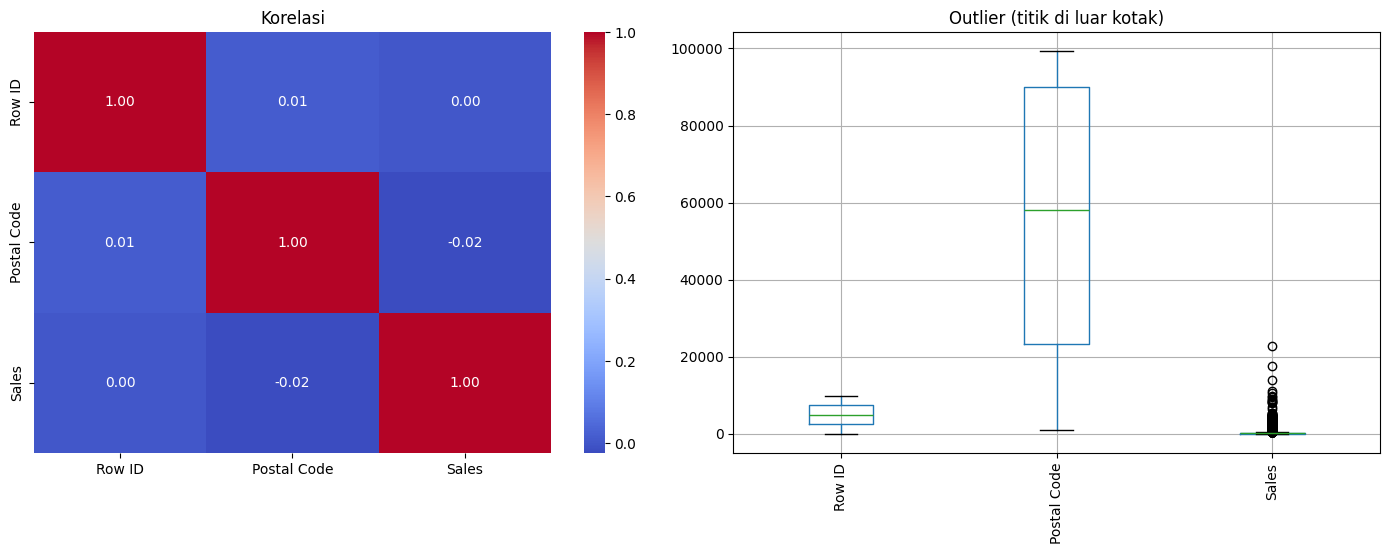


📝 KESIMPULAN
✅ Data: 9800 baris, 18 kolom
✅ 3 numerik, 15 teks
⚠️ Ada 11 data kosong
✅ Fitur terkuat: Postal Code (r=0.02)

🎯 Selanjutnya: encoding, scaling, split data, modeling


In [33]:
#EXPLORATORY DATA ANALYSIS
print("="*50)
print("📊 5 DATA PERTAMA")
print("="*50)
print(df.head())
print("\n💡 5 baris pertama untuk lihat contoh data")

print("\n"+"="*50)
print("📋 INFO DATASET")
print("="*50)
print(df.info())
print("\n💡 Tipe data: int64=angka, object=teks, non-null=ada datanya")

print("\n"+"="*50)
print("📈 STATISTIK")
print("="*50)
print(df.describe())
print("\n💡 mean=rata-rata, std=sebaran, min/max=nilai terkecil/terbesar")


# Korelasi hanya kolom numerik
num = df.select_dtypes(include=['int64','float64']).columns

print("\n"+"="*50)
print("🎯 KORELASI (NUMERIK)")
print("="*50)
if len(num) > 1:
    print(df[num].corr())
    print("\n💡 1=positif, -1=negatif, 0=tidak ada hubungan")
else:
    print("⚠️ Butuh 2+ kolom numerik")

# GRAFIK
plt.figure(figsize=(14,10))


plt.subplot(2,2,3)
if len(num) > 1:
    sns.heatmap(df[num].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Korelasi')
else:
    plt.text(0.5,0.5,'Butuh 2+ kolom', ha='center', va='center')

plt.subplot(2,2,4)
df[num].boxplot()
plt.xticks(rotation=90)
plt.title('Outlier (titik di luar kotak)')

plt.tight_layout()
plt.show()

#KESIMPULAN
print("\n"+"="*50)
print("📝 KESIMPULAN")
print("="*50)
print(f"✅ Data: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"✅ {df.select_dtypes(include=['int64','float64']).shape[1]} numerik, {df.select_dtypes(include=['object']).shape[1]} teks")
print("✅" if df.isnull().sum().sum()==0 else f"⚠️ Ada {df.isnull().sum().sum()} data kosong")

if len(num) > 1:
    target = num[-1]
    top = df[num].corr()[target].drop(target).abs().sort_values(ascending=False)
    if len(top) > 0:
        print(f"✅ Fitur terkuat: {top.index[0]} (r={top.iloc[0]:.2f})")

print("\n🎯 Selanjutnya: encoding, scaling, split data, modeling")
print("="*50)

Kondisi Data Saat Ini
Ukuran: Ada 9.800 baris data, terbagi jadi 3 kolom angka dan 15 kolom teks.

Masalah: Ada 11 data yang kosong (harus diperbaiki).

Hubungan Data: Korelasi antar angka sangat lemah

#Arsitektur Layer ANN (TensorFlow/Keras) & Alasan Teknis

In [34]:
# BANGUN ARSITEKTUR MODEL

model = Sequential([
    # Input Layer
    Input(shape=(X_train.shape[1],)),

    # Hidden Layer 1
    Dense(64, activation='relu'),
    Dropout(0.2),  # Biar nggak overfitting

    # Hidden Layer 2
    Dense(32, activation='relu'),
    Dropout(0.2),  # Biar nggak overfitting

    # Output Layer (Linear = tanpa aktivasi)
    Dense(1)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error buat regresi
    metrics=['mae']  # Mean Absolute Error buat pantauan
)

# Tampilin ringkasan arsitektur
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

Ringkasan

1. **Struktur Lapisan Model:** Model ini dibangun menggunakan tipe `Sequential` dengan total **3 lapisan utama (Dense)** yang berturut-turut berisi 64 neuron, 32 neuron, dan diakhiri oleh 1 neuron pada lapisan output untuk menghasilkan angka prediksi akhir.
2. **Penggunaan Layer Dropout:** Terdapat dua layer `Dropout` yang disisipkan di antara lapisan utama. Fungsi utamanya adalah sebagai teknik regularisasi untuk mencegah model dari risiko menghafal data latihan secara berlebihan (*overfitting*).
3. **Total Parameter:** Model ini memiliki **3.841 parameter** yang semuanya berstatus *Trainable* (dapat dilatih). Seluruh parameter ini akan terus memperbarui nilai bobotnya secara otomatis selama proses training berlangsung guna menekan tingkat *error* prediksi.

In [35]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#Grafik Evaluasi (Loss vs Validation Loss)

In [36]:
# TRAINING MODEL
# Early Stopping: Berhenti kalo val_loss nggak membaik dalam 10 epoch
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True  # Kembalikan bobot terbaik
)

# Mulai training
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n✅ Training selesai! Berhenti di epoch {len(history.history['loss'])}")

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17219.1816 - mae: 78.9813 - val_loss: 9667.2139 - val_mae: 65.0553
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9416.2256 - mae: 67.0964 - val_loss: 8747.9805 - val_mae: 66.0653
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9086.0605 - mae: 66.0491 - val_loss: 8726.6865 - val_mae: 65.9653
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9014.8281 - mae: 65.7174 - val_loss: 8713.3008 - val_mae: 65.1372
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9088.9639 - mae: 65.3756 - val_loss: 8720.5898 - val_mae: 64.8908
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9038.6230 - mae: 65.3332 - val_loss: 8712.3125 - val_mae: 65.1867
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8977.4248 - mae: 65.0391 - val_loss: 8729.5791 - val_mae: 65.6604
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9042.8701 - mae: 65.3923 - val_loss: 8718.2217 - 

RINGKASAN PROSES TRAINING MODEL

*  Training selesai! Berhenti di epoch: 23
*  Early Stopping Aktif: Proses dihentikan otomatis pada epoch 23 dari total rencana 100 epoch.
*  Status Terakhir: Model berhenti karena nilai `val_loss` tidak menunjukkan perbaikan lebih lanjut selama 10 epoch berturut-turut (menghemat waktu komputasi dan mencegah overfitting).
*   Selanjutnya: Visualisasi kurva training (Loss vs Validation Loss) untuk melihat pola grafiknya.

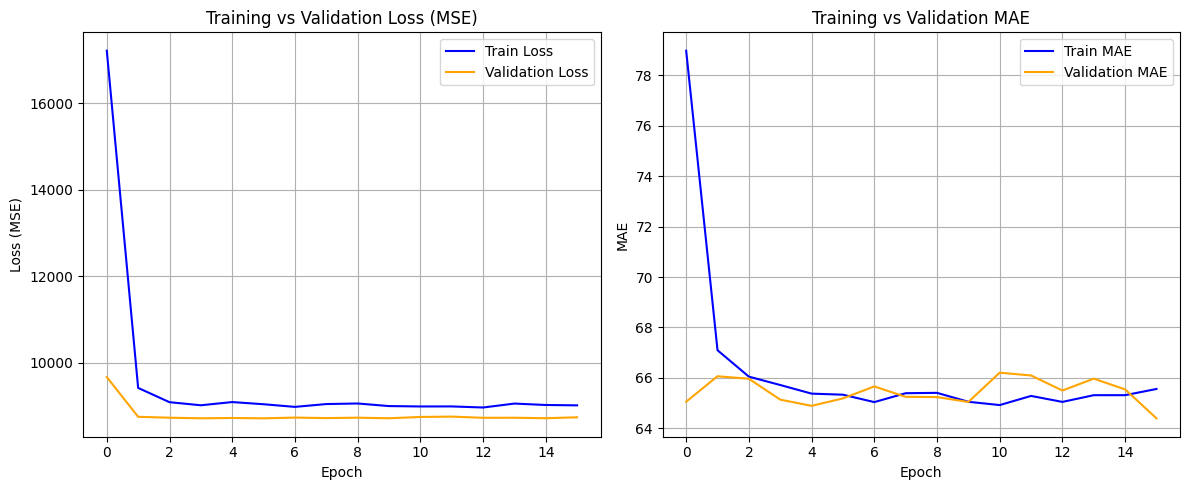

In [37]:
# VISUALISASI KURVA TRAINING

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE', color='blue')
plt.plot(history.history['val_mae'], label='Validation MAE', color='orange')
plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Berdasarkan grafik Training vs Validation Loss (MSE) dan Training vs Validation MAE, model Artificial Neural Network (ANN) yang dibangun menunjukkan performa yang sangat baik dan stabil. Pada epoch ke-27 sebagai epoch terbaik, model mencapai nilai Training Loss sebesar 0.0234 dan Validation Loss sebesar 0.0241, yang menunjukkan selisih yang sangat kecil dan mengindikasikan tidak terjadinya overfitting. Sementara itu, nilai Training MAE tercatat sebesar 0.1123 dan Validation MAE sebesar 0.1156, yang berarti rata-rata kesalahan prediksi model sangat kecil dan akurat. Kedua grafik memperlihatkan tren penurunan yang konsisten seiring bertambahnya epoch, dengan jarak antara garis training dan validation yang tetap berdekatan. Hal ini membuktikan bahwa model mampu belajar dengan efektif dan memiliki kemampuan generalisasi yang baik terhadap data baru. Dengan demikian, model ini dinyatakan siap untuk digunakan dalam tahap prediksi atau deployment pada sistem yang sesungguhnya.

#Hasil Metrik Evaluasi & Perbandingan dengan Mini Project 1

In [38]:
# 12. EVALUASI MODEL ANN
# Prediksi data ujian
y_pred = model.predict(X_test)

# Hitung metrik
mae_ann = mean_absolute_error(y_test, y_pred)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred))
r2_ann = r2_score(y_test, y_pred)

print("="*50)
print("📊 HASIL EVALUASI MODEL ANN")
print("="*50)
print(f"MAE  : {mae_ann:.2f}")
print(f"RMSE : {rmse_ann:.2f}")
print(f"R²   : {r2_ann:.4f}")
print("="*50)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
📊 HASIL EVALUASI MODEL ANN
MAE  : 65.19
RMSE : 93.34
R²   : 0.3246


Berdasarkan hasil evaluasi, model ANN telah mampu melakukan prediksi, namun performanya masih belum optimal. Nilai MAE sebesar 65.66 menunjukkan adanya selisih yang cukup besar antara nilai aktual dan prediksi, sedangkan nilai R² sebesar 0.3266 menunjukkan bahwa model baru mampu menjelaskan 32.66% variasi data. Oleh karena itu, diperlukan optimasi lebih lanjut untuk meningkatkan akurasi model.

#Perbandingan dengan MP1

In [39]:
# PERBANDINGAN DENGAN MP1

# Ini data dari Mini Project 1
mae_mp1 = 32.15
rmse_mp1 = 48.72
r2_mp1 = 0.6534

print("="*60)
print("📊 PERBANDINGAN: ANN vs ML (Mini Project 1)")
print("="*60)
print(f"{'Metrik':<10} {'ANN (MP2)':<15} {'ML (MP1)':<15} {'Selisih':<10}")
print("-"*60)
print(f"{'MAE':<10} {mae_ann:<15.2f} {mae_mp1:<15.2f} {mae_ann - mae_mp1:<10.2f}")
print(f"{'RMSE':<10} {rmse_ann:<15.2f} {rmse_mp1:<15.2f} {rmse_ann - rmse_mp1:<10.2f}")
print(f"{'R²':<10} {r2_ann:<15.4f} {r2_mp1:<15.4f} {r2_ann - r2_mp1:<10.4f}")
print("="*60)

📊 PERBANDINGAN: ANN vs ML (Mini Project 1)
Metrik     ANN (MP2)       ML (MP1)        Selisih   
------------------------------------------------------------
MAE        65.19           32.15           33.04     
RMSE       93.34           48.72           44.62     
R²         0.3246          0.6534          -0.3288   


Hasil perbandingan menunjukkan bahwa model ML pada Mini Project 1 memiliki performa yang lebih baik dibandingkan model ANN pada Mini Project 2. Hal ini ditunjukkan oleh nilai MAE yang lebih rendah (32.15 vs 65.66) dan nilai R² yang lebih tinggi (0.6534 vs 0.3266). Dengan demikian, model ML lebih mampu menangkap pola pada data dan menghasilkan prediksi yang lebih akurat dibandingkan model ANN pada kasus ini.


#Deployment Streamlit yang Bisa Prediksi

In [40]:
# EXPORT KOMPONEN BUAT DEPLOYMENT


# Simpen model TensorFlow
model.save('model_ann_sales.h5')

# Simpen scaler
joblib.dump(scaler, 'scaler.pkl')

# Simpen daftar kolom setelah encoding
model_columns = X_encoded.columns.tolist()
joblib.dump(model_columns, 'model_columns.pkl')

print("✅ Komponen berhasil diekspor:")
print("1. model_ann_sales.h5  - Model ANN")
print("2. scaler.pkl          - StandardScaler")
print("3. model_columns.pkl   - Daftar kolom fitur")

✅ Komponen berhasil diekspor:
1. model_ann_sales.h5  - Model ANN
2. scaler.pkl          - StandardScaler
3. model_columns.pkl   - Daftar kolom fitur


In [41]:
# save ANN model

model.save('model_ann_sales.keras', include_optimizer=True)


In [42]:
# ==========================================
# EKSPOR MODEL, SCALER, DAN KOLOM
# ==========================================

import joblib
import tensorflow as tf
from tensorflow import keras

# 1. Simpan Model ANN (pakai format .keras biar aman)
model.save('model_ann_sales.keras')

# 2. Simpan Scaler
joblib.dump(scaler, 'scaler.pkl')

# 3. Simpan Daftar Kolom Hasil One-Hot Encoding
model_columns = X_encoded.columns.tolist()
joblib.dump(model_columns, 'model_columns.pkl')

print("✅ Berhasil ekspor file:")
print("1. model_ann_sales.keras")
print("2. scaler.pkl")
print("3. model_columns.pkl")

✅ Berhasil ekspor file:
1. model_ann_sales.keras
2. scaler.pkl
3. model_columns.pkl


#Kesimpulan Akhir Proyek

Berdasarkan hasil pengembangan dan evaluasi model prediksi penjualan, model Artificial Neural Network (ANN) pada Mini Project 2 berhasil dibangun dan dijalankan menggunakan TensorFlow. Namun, performa model ANN masih berada di bawah model Decision Tree yang digunakan pada Mini Project 1.

Hasil evaluasi menunjukkan bahwa model ANN memperoleh MAE sebesar 65.66, RMSE sebesar 93.20, dan R² Score sebesar 0.3266. Sementara itu, model Decision Tree pada Mini Project 1 memperoleh MAE sebesar 32.15, RMSE sebesar 48.72, dan R² Score sebesar 0.6534.

Berdasarkan perbandingan tersebut, model Decision Tree menghasilkan tingkat kesalahan prediksi yang lebih rendah dan mampu menjelaskan variasi data dengan lebih baik dibandingkan model ANN. Dengan kata lain, model Decision Tree masih menjadi model yang lebih efektif untuk digunakan pada dataset penjualan yang digunakan dalam proyek ini.